### meteo.data.gouv.fr SIM2 MENSUEL (SAFRAN) - Cartographie par POLYGONE de l'écart à la moyenne pour un paramètre et un mois choisis
Environnement python 3.11.8 (numpy V1.26.4 qui n'est pas encore en V2).<br>
Ajout du graphique chronologique des indices de sécheresse SSWI (mais non cartographiés)

- data : [meteo.data.gouv.fr](https://meteo.data.gouv.fr/)
- Auteur: L. Duffar
--------------------------------------------------------------
C'est le 3ème script de la chaine de traitement des données SIM2 MENSUELLES 
- Un 1er script permet de générer le fichier PARQUET de tous les paramètres pour la France entière, à partir des fichiers CSV originaux téléchargés automatiquement)
- Un 2ème script de traitement par maille est indispensable pour générer un fichier EXCEL indispensable au 3ème script
- Le présent 3ème script de traitement par polygone utilise le fichier EXCEL créé précédemment pour générer des cartes/graphiques agrégés par  polygones quelconques, départements ou bassins-versants (= moyenne des mailles pour chaque polygone et pour chaque paramètre SIM2)
--------------------------------------------------------------
NB: Le présent script traite uniquement un tableau 2D représentant la moyenne par polygone (dataframe pandas, et non 3D rasters xarray représentant des cartes des mailles)

- La statistique (écart à la moyenne et période de retour) est établie sur une période choisie par l'utilisateur (impérativement incluse dans la période contenue dans le fichier Excel).
- SSWI en plus : le script trace également le graphique chronologique des index SSWI de 1 à 12 mois OPTIONNEL

#### 1- Initialisation & Lecture du fichier Excel de l'historique agrégé par POLYGONE

In [16]:
#================================
# Auteur: L. Duffar
# Mars 2024
#================================
import pandas as pd
import geopandas as gpd
import os
from datetime import datetime
import locale
locale.setlocale(locale.LC_ALL, 'fr_FR.UTF-8')
pd.options.mode.copy_on_write = True # ajout imposé par environnement du nouveau PC LDU (voir lien ci-dessous)
# https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

# ============= Personalisation =============
folder_in= r'X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025'
file_in= 'SIM2_MENS_Verdon+Durance+Siagne+Biançon_1958-08_2024-05_polygones.xlsx'
file_in= 'SIM2_MENS_PACA_1958-08_2025-05_Départements PACA.xlsx'
file_in= 'SIM2_MENS_PACA_1958-08_2025-07_départements PACA avec SSWI1-12.xlsx'

folder_out= folder_in
# nom_champ_polygone = 'code' # champ initial du fichier shape contenant l'identifiant voulu pour les polygones
nom_champ_polygone = 'nom' # champ initial du fichier shape contenant l'identifiant voulu pour les polygones
nom_colonne_polygone = 'NOM' # nom de colonne renommé pour l'identifiant de polygone dans le geodataframe tiré du fichier shape

# ============= Initialisation  =============
print(datetime.now().strftime('%d/%m/%y %H:%M'))

data_sheet= 'data'
# mois_noms = ["Janvier", "Février", "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"]
# Mappage des mois pour la légende
mois_map = {1: "Janvier", 2: "Février", 3: "Mars", 4: "Avril", 5: "Mai", 6: "Juin",
            7: "Juillet", 8: "Août", 9: "Septembre", 10: "Octobre", 11: "Novembre", 12: "Décembre"}
sec_humide= ['sec', 'humide']
froid_chaud= ['froid', 'chaud']
faible_fort= ['faible', 'fort']
non_pertinent= None # pour le script "traitement par polygone" cette variable concernant la période de retour n'est pas pertinente pour les indices SSWI qui représentent déjà une période de de retour
# définition des paramètres SAFRAN ORIGINAUX CONTENUS DANS LE FICHIER et de leur représentation graphique (NON PAS LE PAREMETRE MAIS l'Ecart à la moyenne, ou en °C pour la température)
# param_dict= {'PRENEI_MENS': ['Précip. solides', 'mm', 'RdBu', [0, 4], sec_humide], 
#              'PRETOTM_MENS':['Précip. totales', 'mm', 'RdBu', [0, 4], sec_humide], 
#              'T_MENS':['Température moyenne', '°C', 'RdBu_r', [0, 5], froid_chaud], 
#              'EVAP_MENS':['Evaporation réelle', 'mm', 'RdBu_r', [0, 4], faible_fort], 
#              'ETP_MENS':['ETP', 'mm', 'RdBu_r', [0, 4], faible_fort], 
#              'PE_MENS': ['Précipitations efficace', 'mm', 'RdBu', [0, 4], sec_humide],
#              'SWI_MENS':['SWI', 'adimnensionel', 'RdBu', [0, 0.8], sec_humide]
#              }

nom_colonnes= ['nom_clair',           'unité', 'cbar_écart',              'grad_écart', 'bas_haut']
param_array= [
              ['Précip. solides',    "ratio", 'RdBu',                     [0, 4],      sec_humide], # 'PRENEI_MENS', 
              ['Précip. totales',    'ratio', 'RdBu',                     [0, 4],      sec_humide], # 'PRETOTM_MENS', 
              ['Température',        '°C', 'RdBu_r',                      [0, 5],     froid_chaud], # 'T_MENS', 
              ['Evaporation réelle', 'ratio', 'RdBu_r',                   [0, 4],     faible_fort], # 'EVAP_MENS', 
              ['ETP',                'ratio', 'RdBu_r',                   [0, 4],     faible_fort], # 'ETP_MENS', 
              ['SWI',                'ratio', 'RdBu',                     [0, 0.8],    sec_humide],# 'SWI_MENS',
              ['SSWI1',              'var.norm.centrée.réduite', 'RdBu',  [0, +2.5],    non_pertinent],# 'SSWI1_MENS',
              ['SSWI3',              'var.norm.centrée.réduite', 'RdBu',  [0, +2.5],    non_pertinent],# 'SSWI3_MENS', 
              ['SSWI6',              'var.norm.centrée.réduite', 'RdBu',  [0, +2.5],    non_pertinent],# 'SSWI6_MENS', 
              ['SSWI12',              'var.norm.centrée.réduite', 'RdBu', [0, +2.5],    non_pertinent],# 'SSWI12_MENS', 
            ]
nom_index= ['PRENEI_MENS', 'PRETOTM_MENS', 'T_MENS', 'EVAP_MENS', 'ETP_MENS', 'SWI_MENS', 'SSWI1_MENS', 'SSWI3_MENS', 'SSWI6_MENS', 'SSWI12_MENS']
param_df= pd.DataFrame(param_array, index= nom_index, columns= nom_colonnes)

# ============= Lecture du fichier Excel issu du script de traitement par MAILLE (moyennes des mailles des paramètres pour chacun des polygone)  =============
print('Lecture du fichier Excel')
df= pd.read_excel(os.path.join(folder_in, file_in), sheet_name= data_sheet, skiprows= 0, dtype= {nom_colonne_polygone: str}) # Lecture du fichier 

df.set_index([nom_colonne_polygone, 'DATE'], inplace= True)
df

02/08/25 21:18
Lecture du fichier Excel


PRENEI_MENS  PRETOTM_MENS     PE_MENS     T_MENS  \
NOM             DATE                                                           
Alpes-Maritimes 1958-08-01     0.000000     59.301639   -3.132787  17.165574   
                1958-09-01     0.000000     91.640984   49.157377  15.163934   
                1958-10-01     0.321311    114.777049   67.673770   9.570492   
                1958-11-01     7.696721     90.554098   70.477049   6.019672   
                1958-12-01    75.139344    312.218033  299.740984   2.642623   
...                                 ...           ...         ...        ...   
Vaucluse        2025-03-01     0.622449    121.530612   68.487755   8.791837   
                2025-04-01     0.000000     99.451020   28.830612  13.044898   
                2025-05-01     0.000000     61.946939  -38.875510  16.638776   
                2025-06-01     0.000000     17.330612  -47.538776  24.124490   
                2025-07-01     0.000000     32.159184  -18.385714  23.469388   

                             EVAP_MENS    ETP_MENS  SWI_MENS  SSWI1_MENS  \
NOM             DATE                                                       
Alpes-Maritimes 1958-08-01   62.444262  136.052459  0.380869    0.923770   
                1958-09-01   42.495082   89.337705  0.347869    0.214590   
                1958-10-01   47.106557   51.513115  0.709869    0.608197   
                1958-11-01   20.080328   25.009836  0.749590   -0.331967   
                1958-12-01   12.424590   22.555738  0.931508    0.541639   
...                                ...         ...       ...         ...   
Vaucluse        2025-03-01   53.032653   67.226531  0.796673    0.662653   
                2025-04-01   70.618367   89.144898  0.782714    1.469184   
                2025-05-01  100.834694  149.426531  0.695878    0.790816   
                2025-06-01   64.869388  197.487755  0.424143   -0.220816   
                2025-07-01   50.546939  202.059184  0.275469   -0.393878   

                            SSWI3_MENS  SSWI6_MENS  SSWI12_MENS  
NOM             DATE                                             
Alpes-Maritimes 1958-08-01         NaN         NaN          NaN  
                1958-09-01         NaN         NaN          NaN  
                1958-10-01    0.527705         NaN          NaN  
                1958-11-01    0.209180         NaN          NaN  
                1958-12-01    0.298197         NaN          NaN  
...                                ...         ...          ...  
Vaucluse        2025-03-01   -0.343673   -0.577347    -0.144082  
                2025-04-01    0.641020   -0.466327    -0.123061  
                2025-05-01    1.117143   -0.043673    -0.096122  
                2025-06-01    0.709184    0.231633    -0.145102  
                2025-07-01    0.168571    0.505510    -0.206122  

[4824 rows x 11 columns]

#### 2- Calcul du cumul depuis septembre, pour chaque polygone indépendamment 
NB: uniquement pour les paramètres choisies pour lequels le cumul a un sens, notamment précipitations

In [17]:
# Calcul du cumul de certains paramètres depuis septembre (notamment précipitations), pour chaque polygone individuellement
#================================
# Auteur: L. Duffar
# Mars 2024
#================================
import hvplot.pandas

############# Initialisation
print(datetime.now().strftime('%d/%m/%y %H:%M'))
# paramètres à cumuler depuis septembre, uniquement pour ceux pour lequel le cumul est pertinent
param_to_cumulate_list= ['PRETOTM_MENS', 'PRENEI_MENS']
# copy du dictionnaire des paramètres initiaux pour y ajouter les paramètres calculés (cumuml depuis septembre)
# param_dict2= param_dict.copy()
param_df2= param_df.copy()

############# Traitement
df.reset_index(inplace= True) # ajout imposé par environnement du nouveau PC LDU
for param_to_cumulate in param_to_cumulate_list: 
    # boucle sur les paramètres à cumuler pour ajouter au dataframe initial de nouvelles colonnes de cumul depuis septembre
    print('Calcul du cumul de ', param_to_cumulate)    
    param_cumulated= 'cumul_' + param_to_cumulate
    # param_dict2[param_cumulated]= [param_dict[param_to_cumulate][0] + ' depuis SEPTEMBRE', 'mm', 'RdBu', [0, 2], sec_humide] # version dictionnaire
    # ajout d'un élément au dataframe param_df avec la définition des nouveaux paramètres à traiter et de leurs caractéristiques graphiques
    param_df2.loc[param_cumulated]= [param_df.loc[param_to_cumulate, 'nom_clair'] + ' depuis SEPTEMBRE', 'mm', 'RdBu', [0, 2], sec_humide] # version dataframe
    # Fonction pour calculer le cumul de précipitations depuis septembre
    # fonction définie pour un group (=polygone, car la fonction est appelée par df.groupby(level= nom_colonne_polygone).apply(cumul_depuis_septembre))
    def cumul_depuis_septembre(group): 
        # Créer la colonne group[param_cumulated], mais sans dupliquer l'index nom_colonne_polygone
        group[param_cumulated]= 0
        group.reset_index(inplace= True, drop= True) # ajout imposé par environnement du nouveau PC LDU
        # Marquer les mois de septembre
        # est_septembre = group.index.get_level_values('DATE').month == 9
        est_septembre = group['DATE'].dt.month == 9 # modif imposée par environnement du nouveau PC LDU
        # Parcourir chaque ligne du groupe
        for i in range(len(group)): 
            # boucle sur les dates d'un group/polygone
            if est_septembre[i]:
                # Pour septembre, le cumul est égal aux précipitations de septembre seul
                group.iloc[i, group.columns.get_loc(param_cumulated)] = group.iloc[i, group.columns.get_loc(param_to_cumulate)]
            else:
                # Pour les autres mois, ajouter les précipitations du mois au cumul du mois précédent
                group.iloc[i, group.columns.get_loc(param_cumulated)] = group.iloc[i-1, group.columns.get_loc(param_to_cumulate)] + \
                                                                        group.iloc[i, group.columns.get_loc(param_to_cumulate)]
        return group

    # Appliquer la fonction à chaque polygone
    # df = df.groupby(level= nom_colonne_polygone).apply(cumul_depuis_septembre)
    df = df.groupby(nom_colonne_polygone).apply(cumul_depuis_septembre, include_groups= True) # modif imposée par environnement du nouveau PC LDU
    df.reset_index(inplace= True, drop= True) # ajout imposé par environnement du nouveau PC LDU
             
df.set_index([nom_colonne_polygone, 'DATE'], inplace= True)
# Aperçu du DataFrame modifié
df.hvplot.table()

02/08/25 21:18
Calcul du cumul de  PRETOTM_MENS


C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:42: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '94.85901639344262' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:42: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '120.09462365591396' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:42: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '48.173913043478265' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:42: FutureWarni

Calcul du cumul de  PRENEI_MENS


C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:42: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.75625' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:42: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2617283950617284' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:42: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.02653061224489796' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\DUFFAR\AppData\Local\Temp\ipykernel_19860\2636617522.py:48: DeprecationWarning:


:Table   [NOM,DATE,PRENEI_MENS,PRETOTM_MENS,PE_MENS,T_MENS,EVAP_MENS,ETP_MENS,SWI_MENS,SSWI1_MENS,SSWI3_MENS,SSWI6_MENS,SSWI12_MENS,cumul_PRETOTM_MENS,cumul_PRENEI_MENS]

#### 3- Ecart à la moyenne et fréquence de chaque valeur mensuelle, pour chaque groupe (polygone-mois) et chaque paramètre
A FAIRE: Etudier si d'autre paramètre que la température doivent être traités en écart brut plustôt qu'en ratio

Les colonnes pour les données calculées suivantes sont ajoutée à une copie du dataframe initial filtrée sur la période d'intérêt
- Fréquence empirique de chaque donnée mensuelle 
- Moyenne des mailles pour chaque polygone fournis en fichier shape
- Ecart à la moyenne (en ratio, ou en °C pour température)

NB: l' "écart à la moyenne" est un pourcentage (négatif ou positif), sauf pour la température dont l'écart est exprimé en °C

TODO: permettre le calcul sur une date en dehors de la période de référence. Par exemple sur février 2025 avec une référence 1991-2020
Cela complique un peu le calcul qui doit se faire en 2 passes:
- Passe 1: Le calcul est réalisé sans changement, mais avec df_filtered filtré sur la période de référence (par exemple 1991-2020)
- Passe 2: Le calcul est à nouveau réalisé sur un dataframe supplémentaire df_result
  - L'écart est recalculé par rapport à la moyenne précédemment calculée sur la période de référence
  - La subilité est que la fréquence empirique n'est pas calculée par le simple rang (puisque toutes les dates hors référence n'ont pas de rang),
    mais par interpolatioon dans  la table df_filtered

In [18]:
# Caractérisation de chaque valeur mensuelle SAFRAN, pour tous les groupes département-mois et pour chaque paramètres
#================================
# Auteur: L. Duffar
# Mars 2024
#================================

############ Personalisation
# Période d'intérêt (ne peut être en dehors de la période contenue dans le fichier Excel)
debut_periode = '1991-01-01'
fin_periode = '2025-07-01'

############ Calcul de l'écart à la moyenne (en pourcent pour les paramètres toujours positifs &  en °C pour la température)
print(datetime.now().strftime('%d/%m/%y %H:%M'), "Calcul de la fréquence empirique, de la moyenne et de l'écart à la moyenne")
print("NB: L'écart à la moyenne est exprimé en °C pour la température, ou en ratio par rapport à la moyenne pour les autres paramètres.")
# Filtrer le DataFrame pour la période d'intérêt
df_filtered = df.loc[(df.index.get_level_values('DATE') >= debut_periode) & 
                     (df.index.get_level_values('DATE') <= fin_periode)]

# for param in list(param_dict2.keys()):
for _, row in param_df2.iterrows():
    param= row.name
# Calculer la fréquence empirique
    def calculer_frequence(df, param):
        # Grouper par département et mois, en considérant uniquement le mois de la date
        grouper = df.groupby([df.index.get_level_values(nom_colonne_polygone), df.index.get_level_values('DATE').month])
        # Calculer la fréquence pour chaque groupe
        def frequence_empirique(x):
            rangs = x.rank(method='min')
            taille_echantillon = len(x)
            return rangs / (taille_echantillon + 1)
        return grouper[param].transform(frequence_empirique)

    # Calculer le delta par rapport à la moyenne (en pourcentage ou en °C pour la tempétature)
    def calculer_delta(df, param):
        # Grouper par département et mois, en considérant uniquement le mois de la date
        grouper = df.groupby([df.index.get_level_values(nom_colonne_polygone), df.index.get_level_values('DATE').month])        
        def delta(x):
            moy = x.mean()
            if param == 'T_MENS':
                return (x - moy) # en °C
            else:
                return (x - moy  ) / moy # ratio par rapport à la moyenne
        return grouper[param].transform(delta)

    # Calculer la moyenne (pour contrôle du code, car elle ne sera pas forcément utilisée)
    def calculer_moyenne(df, param):
        # Grouper par département et mois, en considérant uniquement le mois de la date
        grouper = df.groupby([df.index.get_level_values(nom_colonne_polygone), df.index.get_level_values('DATE').month])        
        def moyenne(x):
            return x.mean()
        return grouper[param].transform(moyenne)    

    # Ajouter au DataFrame filtré les colonnes freq, delta et moy
    col_freq= 'freq_' + param
    col_delta= 'delta_' + param
    col_moy= 'moy_' + param
    # df_filtered[col_freq] = calculer_frequence(df_filtered, param)
    # df_filtered[col_delta] = calculer_delta(df_filtered, param)
    # df_filtered[col_moy] = calculer_moyenne(df_filtered, param)
    df_filtered.loc[:, col_freq] = calculer_frequence(df_filtered, param)
    df_filtered.loc[:, col_delta] = calculer_delta(df_filtered, param)
    df_filtered.loc[:, col_moy] = calculer_moyenne(df_filtered, param)

# Afficher le résultat
display(df_filtered)

02/08/25 21:18 Calcul de la fréquence empirique, de la moyenne et de l'écart à la moyenne
NB: L'écart à la moyenne est exprimé en °C pour la température, ou en ratio par rapport à la moyenne pour les autres paramètres.


PRENEI_MENS  PRETOTM_MENS     PE_MENS     T_MENS  \
NOM             DATE                                                           
Alpes-Maritimes 1991-01-01     7.416393     16.439344    7.219672   1.693443   
                1991-02-01    33.444262     57.509836   47.642623  -0.165574   
                1991-03-01    26.172131    140.198361  107.545902   5.690164   
                1991-04-01    24.922951     58.822951   12.885246   4.724590   
                1991-05-01    18.555738     73.881967    6.573770   7.680328   
...                                 ...           ...         ...        ...   
Vaucluse        2025-03-01     0.622449    121.530612   68.487755   8.791837   
                2025-04-01     0.000000     99.451020   28.830612  13.044898   
                2025-05-01     0.000000     61.946939  -38.875510  16.638776   
                2025-06-01     0.000000     17.330612  -47.538776  24.124490   
                2025-07-01     0.000000     32.159184  -18.385714  23.469388   

                             EVAP_MENS    ETP_MENS  SWI_MENS  SSWI1_MENS  \
NOM             DATE                                                       
Alpes-Maritimes 1991-01-01    9.181967   20.672131  0.853934    0.087705   
                1991-02-01    9.847541   25.245902  0.830164   -0.031639   
                1991-03-01   32.631148   47.881967  0.951754    1.130492   
                1991-04-01   45.903279   70.796721  0.865754    0.607705   
                1991-05-01   67.296721   95.165574  0.827262    0.461311   
...                                ...         ...       ...         ...   
Vaucluse        2025-03-01   53.032653   67.226531  0.796673    0.662653   
                2025-04-01   70.618367   89.144898  0.782714    1.469184   
                2025-05-01  100.834694  149.426531  0.695878    0.790816   
                2025-06-01   64.869388  197.487755  0.424143   -0.220816   
                2025-07-01   50.546939  202.059184  0.275469   -0.393878   

                            SSWI3_MENS  SSWI6_MENS  ...  moy_SSWI6_MENS  \
NOM             DATE                                ...                   
Alpes-Maritimes 1991-01-01    0.027869   -0.007541  ...       -0.041251   
                1991-02-01    0.126885   -0.033607  ...       -0.028585   
                1991-03-01    0.511803    0.404426  ...        0.000731   
                1991-04-01    0.731803    0.523934  ...       -0.002290   
                1991-05-01    0.989180    0.833607  ...        0.024094   
...                                ...         ...  ...             ...   
Vaucluse        2025-03-01   -0.343673   -0.577347  ...       -0.081289   
                2025-04-01    0.641020   -0.466327  ...       -0.076245   
                2025-05-01    1.117143   -0.043673  ...       -0.045178   
                2025-06-01    0.709184    0.231633  ...       -0.055755   
                2025-07-01    0.168571    0.505510  ...       -0.046443   

                            freq_SSWI12_MENS  delta_SSWI12_MENS  \
NOM             DATE                                              
Alpes-Maritimes 1991-01-01          0.361111           5.902428   
                1991-02-01          0.416667           5.217579   
                1991-03-01          0.472222          -0.479907   
                1991-04-01          0.527778          -6.622692   
                1991-05-01          0.555556         -39.924356   
...                                      ...                ...   
Vaucluse        2025-03-01          0.500000           0.732333   
                2025-04-01          0.527778           0.709045   
                2025-05-01          0.527778           0.349460   
                2025-06-01          0.500000           0.907627   
                2025-07-01          0.472222           1.651913   

                            moy_SSWI12_MENS  freq_cumul_PRETOTM_MENS  \
NOM             DATE                                                   
Alpes-

#### Affichage du dataframe dans l'explorateur web avec PANEL pour vérification - OPTIONNEL

In [4]:
# import hvplot.pandas
# import panel as pn

# # table avec hvplot pour pandas
# print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
# table= df_filtered.hvplot.table(width=1650, height=800)

# # affichage de la table hvplot dans l'explorateur web avec panel
# pn.extension()# prepare panel pour afficher table dans l'explorateur
# pn.serve(table)# affiche table dans l'explorateur avec panel

#### 4- Lecture du fichier des polygones

02/08/2025 21:18


,id,code,nom,coderegion,region,geometry
5,06,06,Alpes-Maritimes,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((7.07377 43.51540, 7.07384 43.5..."
1,04,04,Alpes-de-Haute-Provence,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.63131 44.15042, 5.63345 44.1..."
3,13,13,Bouches-du-Rhône,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.38534 43.18909, 5.38521 43.1..."
0,05,05,Hautes-Alpes,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.95112 44.75962, 5.95166 44.7..."
2,83,83,Var,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((6.25870 42.99672, 6.25865 42.9..."
4,84,84,Vaucluse,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((4.89536 44.33817, 4.89156 44.3..."


,id,code,coderegion,region,geometry
NOM,,,,,
Alpes-Maritimes,06,06,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((7.07377 43.51540, 7.07384 43.5..."
Alpes-de-Haute-Provence,04,04,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.63131 44.15042, 5.63345 44.1..."
Bouches-du-Rhône,13,13,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.38534 43.18909, 5.38521 43.1..."
Hautes-Alpes,05,05,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.95112 44.75962, 5.95166 44.7..."
Var,83,83,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((6.25870 42.99672, 6.25865 42.9..."
Vaucluse,84,84,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((4.89536 44.33817, 4.89156 44.3..."


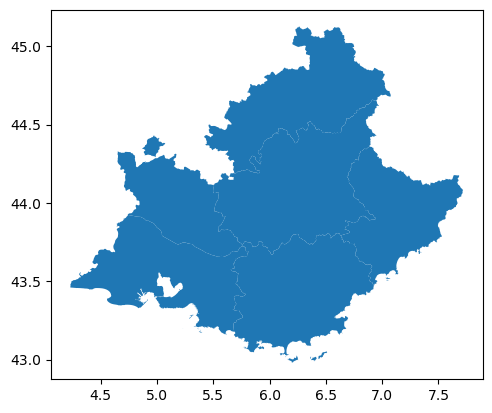

In [19]:
import matplotlib.pyplot as plt
import matplotlib
import cartopy
import cartopy.feature as cfeature

############ Personalisation
# fichier SHP des polygones (multi-polygones dans une couche unique)
file_polygones= r"X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\SIM2\out\shp\BV_Verdon+Durance+Siagne+Biançon.gpkg"
file_polygones= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Départements PACA.gpkg"

############ Traitement
print(datetime.now().strftime('%d/%m/%Y %H:%M'))
# lire avec geopandas un fichier shape des polygones de département PACA 
gdf = gpd.read_file(file_polygones)
# tri des polygones par ordre alphabétique du champ nommé COMMENT NOMMER CE CHAMP ?
gdf = gdf.sort_values(by= nom_champ_polygone)
display(gdf)
gdf.set_index('nom', inplace= True)
# rename index
gdf.index.rename(nom_colonne_polygone, inplace= True)
gdf.plot()
gdf

#### Liste des données pour vérification --> par ordre de FREQUENCE CROISSSANTE, pour chaque polygone et mois - OPTIONNEL

In [6]:
# # dans 2 boucles imbriquées sur les polygones et les 12 mois, affiche les colonnes température et fréquence empirique de df_filtered
# for dep in gdf.index.tolist():
#     for mois in range(1, 13):
#         df_dep_mois = df_filtered.loc[(df_filtered.index.get_level_values(nom_colonne_polygone) == dep) & 
#                                       (df_filtered.index.get_level_values('DATE').month == mois)]
#         print(f'Département {dep}, Mois {mois_map[mois]}')
#         display(df_dep_mois[[param, col_freq]].sort_values(col_freq))

#### 5- Carte de l'écart à la moyenne des paramètres SIM2 agrégés par polygone
- Pour une date choisie
- Pour l'instant un seul paramètre à la fois (il reste à faire la boucle sur tous les paramètres)

02/08/25 21:24


,id,code,coderegion,region,geometry,delta_PRETOTM_MENS,freq_PRETOTM_MENS,delta_cumul_PRETOTM_MENS,freq_cumul_PRETOTM_MENS,delta_T_MENS,freq_T_MENS,delta_EVAP_MENS,freq_EVAP_MENS
NOM,,,,,,,,,,,,,
Alpes-Maritimes,06,06,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((7.07377 43.51540, 7.07384 43.5...",-0.233579,0.416667,-0.522215,0.111111,0.359063,0.555556,-0.179526,0.222222
Alpes-de-Haute-Provence,04,04,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.63131 44.15042, 5.63345 44.1...",0.058236,0.527778,-0.296012,0.222222,0.193272,0.472222,-0.125609,0.250000
Bouches-du-Rhône,13,13,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.38534 43.18909, 5.38521 43.1...",1.111767,0.861111,-0.152371,0.555556,1.093209,0.777778,0.248495,0.777778
Hautes-Alpes,05,05,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.95112 44.75962, 5.95166 44.7...",0.083583,0.611111,0.006815,0.500000,-0.333571,0.388889,-0.074241,0.222222
Var,83,83,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((6.25870 42.99672, 6.25865 42.9...",0.045483,0.555556,-0.639376,0.166667,0.740529,0.694444,-0.062669,0.472222
Vaucluse,84,84,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((4.89536 44.33817, 4.89156 44.3...",0.092686,0.583333,-0.334991,0.277778,0.486997,0.583333,-0.052625,0.472222


                         id code  coderegion                      region  \
NOM                                                                        
Alpes-Maritimes          06   06          93  Provence-Alpes-Côte d'Azur   
Alpes-de-Haute-Provence  04   04          93  Provence-Alpes-Côte d'Azur   
Bouches-du-Rhône         13   13          93  Provence-Alpes-Côte d'Azur   
Hautes-Alpes             05   05          93  Provence-Alpes-Côte d'Azur   
Var                      83   83          93  Provence-Alpes-Côte d'Azur   
Vaucluse                 84   84          93  Provence-Alpes-Côte d'Azur   

                                                                  geometry  \
NOM                                                                          
Alpes-Maritimes          MULTIPOLYGON (((7.07377 43.51540, 7.07384 43.5...   
Alpes-de-Haute-Provence  MULTIPOLYGON (((5.63131 44.15042, 5.63345 44.1...   
Bouches-du-Rhône         MULTIPOLYGON (((5.38534 43.18909, 5.38521 43.1...   
H

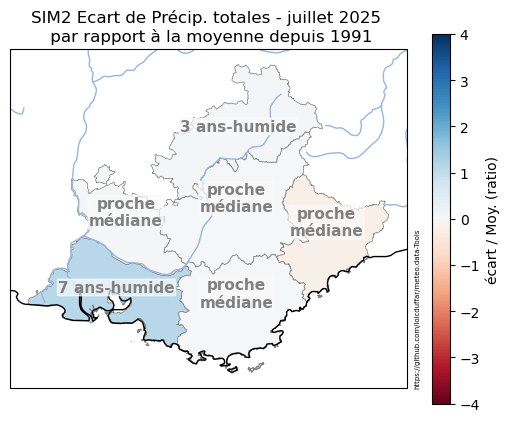

In [25]:
# Carte des paramètres SIM2 agrégé par département
#================================
# Auteur: L. Duffar
# Mars 2024
#================================

############# Personalisation 
# date à représenter sur une carte +++++ TODO la saisie devrait être simultanée pour la date et la période d'intérêt
# ! ATTENTION la date doit être incluse dans la  période d'intérêt
date_to_plot= '2025-07-01'

# parametre à représenter +++++ TODO deviendrait inutile en codant une boucle sur tous les paramètres
# param= 'cumul_PRENEI_MENS'
# param= 'PRENEI_MENS'
# param= 'cumul_PRETOTM_MENS'
param= 'PRETOTM_MENS'
# param= 'SWI_MENS'
# param= 'SSWI1_MENS'
# param= 'T_MENS'
# param= 'EVAP_MENS'

############# Fonction de plot
print(datetime.now().strftime('%d/%m/%y %H:%M'))
def subplots_stat_param_one_date(param= 'cumul_PRETOM_MENS'):
    '''Une page de subplots pour tous les statistique des paramètres prédéterminés et un mois donné'''
    param_to_plot= 'delta_' + param
    param_to_text= 'freq_' + param
    
    if param_to_plot == 'delta_T_MENS':
        unite= 'écart à la Moy. (°C)'
    else:
        unite= 'écart / Moy. (ratio)'

    # extraire les données pour la date à représenter
    df_date_to_plot = df_filtered.loc[df_filtered.index.get_level_values('DATE') == date_to_plot]

    gdf[param_to_plot]= df_date_to_plot[param_to_plot].reset_index(level=1, drop= True)# mono-indexation sur le polygone (retrait de la date)
    gdf[param_to_text]= df_date_to_plot[param_to_text].reset_index(level=1, drop= True)

    # affichage sur une carte cartopy
    ax = plt.axes(projection= cartopy.crs.PlateCarree())

    # dessiner les départements avec une couleur rouge-blanc-bleu en fonction de la valeur (la couleur blanche au milieu correspond à la valeur définie dans le dictionnaire param_dict2[param][3])
    # cmap= param_dict2[param][2]
    # vcenter= param_dict2[param][3][0]
    # vmax= param_dict2[param][3][1]
    cmap= param_df2['cbar_écart'][param]
    vcenter= param_df2['grad_écart'][param][0]
    vmax= param_df2['grad_écart'][param][1]
    vmin= vcenter - vmax

    # Plot
    norm = matplotlib.colors.TwoSlopeNorm(vmin= vmin, vcenter= vcenter, vmax= vmax) # ATTENTION: le zéro n'est pas exactement au centre (pourquoi ?)
    gdf.plot(column= param_to_plot, cmap= cmap, ax= ax, legend= True, norm= norm, linewidth= 0.5, edgecolor= 'gray')

    # Récupérer la colorbar
    cbar = plt.gcf().get_axes()[1]  # get_axes() retourne une liste de tous les axes ; le premier ([0]) est l'axe principal, le second ([1]) est l'axe de la colorbar
    # Ajouter un titre à la colorbar
    cbar.set_ylabel(unite)

    # Ajouter un titre à la carte
    # plt.title(' '.join(['Ecart de', param_dict2[param][0], '-' , datetime.strptime(date_to_plot, '%Y-%m-%d').strftime('%B %Y'), '\n', 
    #                     'par rapport à la moyenne depuis', str(datetime.strptime(debut_periode, '%Y-%m-%d').year)])) # version dictionnaire
    plt.title(' '.join(['SIM2 Ecart de', param_df2['nom_clair'][param], '-' , datetime.strptime(date_to_plot, '%Y-%m-%d').strftime('%B %Y'), '\n', 
                        'par rapport à la moyenne depuis', str(datetime.strptime(debut_periode, '%Y-%m-%d').year) # Verdion dataframe
                        ]
                        )
                    )

    # ajouter la cote et les rivers natural earth
    ax.coastlines()
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_europe', '10m', facecolor='none', edgecolor= '#95B6DE'))  # rien de plus sur PACA (seulement Isère et 1 affluent du Pô)

    # récupérer la figure courante
    fig = plt.gcf()  # get current figure
    # ajouter une annotation en bas à droite de la carte, et à la verticale
    ax.annotate("https://github.com/loicduffar/meteo.data-Tools", 
                xy= (1.02, 0), 
                xycoords='axes fraction',
                fontsize= 5,
                ha='left',
                va= 'bottom',
                color='black',
                rotation= 90)
    
    display(gdf)

    # Afficher la valeur numérique
    for _, row in gdf.iterrows():
        # signe + ou - de l'écart à la moyenne, daprès row[param_to_plot]
        if row[param_to_plot] > 0: # affichage de l'écart à la moyenne
            signe= '+'
        else:
            signe= '-'
        # if param_to_plot == 'delta_T_MENS':
        #     value= f'{signe}{round(row[param_to_plot], 1)}°C'
        # else:
        #     value= f'{signe}{int(round(row[param_to_plot]*100, 0))}%'
        
        # afficher la période de retour humide ou sèche d'après la fréquence dans row[param_to_text]
        tolerance= 0.1
        print(gdf, param_to_text, row[param_to_text])
        if (row[param_to_text] >= (0.5 - tolerance)) and (row[param_to_text] <= (0.5 + tolerance)):
            value= 'proche\nmédiane'
        elif row[param_to_text] > (0.5 + tolerance): # affichage de la période de retour TODO: en cas de record, afficher 'maximum' ou 'minimum' plutôt que la période de retour
            value= f'{int(round(1/(1-row[param_to_text]), 0))} ans-' + param_df2['bas_haut'][param][1]
        elif row[param_to_text] < (0.5 - tolerance):
            value= f'{int(round(1/row[param_to_text], 0))} ans-' + param_df2['bas_haut'][param][0]
        bg_color= (250/255,250/255,250/255,0.7)# gris clair transparent
        ax.text(row.geometry.centroid.x, row.geometry.centroid.y, value, ha='center', fontdict={'size': 11, 'weight': 'bold'}, color='grey',
                bbox=dict(facecolor= bg_color, edgecolor= bg_color, boxstyle='round,pad=0.05'))

############# Affiche une page de subplots par date
# TODO: 
#- boucle à faire sur tous les paramètres (au lieu d'un seul paramètre traité à la fois)
subplots_stat_param_one_date(param= param)
plt.show()

In [8]:
# row[param_to_text]
gdf
# df_date_to_plot
# param_to_text

,id,code,coderegion,region,geometry,delta_T_MENS,freq_T_MENS
NOM,,,,,,,
Alpes-Maritimes,06,06,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((7.07377 43.51540, 7.07384 43.5...",3.841686,0.972222
Alpes-de-Haute-Provence,04,04,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.63131 44.15042, 5.63345 44.1...",4.068295,0.972222
Bouches-du-Rhône,13,13,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.38534 43.18909, 5.38521 43.1...",3.497888,0.972222
Hautes-Alpes,05,05,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.95112 44.75962, 5.95166 44.7...",3.769321,0.972222
Var,83,83,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((6.25870 42.99672, 6.25865 42.9...",3.389982,0.944444
Vaucluse,84,84,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((4.89536 44.33817, 4.89156 44.3...",3.579242,0.944444


#### 6- Graphique à barre par polygone - OPTIONNEL

In [27]:
#####################
# Auteur : L. Duffar
# Date: Juillet 2025
#####################

# faire un graphique plotly à subplots, à 2 colonnes
# il y autant de subplots que de polygones, ce qui détermine le nombre de ligne de subplots
# Les subbplots sont des graphiques à barre pour les mois de l'année à partir du précédent mois de septembre, et jusqu'à la date à représenter (date_to_plot)

import plotly.graph_objects as go
import plotly.express as px
import plotly.subplots as sp
import numpy as np

############# Personalisation 
# date_to_plot = '2025-04-01'  # Date à représenter sur la carte
param= 'T_MENS'

########### Initalisation
print(datetime.now().strftime('%d/%m/%y %H:%M'))
# définir la chaine du mois et de l'année de date_to_plot
mois = datetime.strptime(date_to_plot, '%Y-%m-%d').strftime('%B %Y')
# calculer la date du précédent mois de septembre
date_septembre = pd.to_datetime(date_to_plot).replace(month=9, day=1).strftime('%Y-%m-%d')  # Précédent mois de septembre
# si le mois est inférieur ou égal à septembre, on prend le mois de septembre de l'année précédente
if pd.to_datetime(date_to_plot).month <= 9:
    date_septembre = pd.to_datetime(date_to_plot).replace(year= pd.to_datetime(date_to_plot).year - 1, month=9, day=1).strftime('%Y-%m-%d')

# Filtrer les données pour la date postérieure au mois de septembre
df_date_to_plot = df_filtered.loc[(df_filtered.index.get_level_values('DATE') >= date_septembre) & 
                                   (df_filtered.index.get_level_values('DATE') <= date_to_plot)]

########### Graphique pour le paramètre depuis septembre jusqu'au mois choisi, avec des subplot par polygone
fig = sp.make_subplots(rows=3, cols=2, subplot_titles= df_date_to_plot.index.get_level_values(nom_colonne_polygone).unique().tolist())

# Boucle sur chaque polygone et créer un graphique à barres pour chaque polygone
for i, dep in enumerate(df_date_to_plot.index.get_level_values(nom_colonne_polygone).unique()):
    row = i // 2 + 1  # Calculer le numéro de ligne
    col = i % 2 + 1   # Calculer le numéro de colonne
    
    # Extraire les données pour le département courant
    df_dep = df_date_to_plot.loc[dep]
    mois_abbr= df_dep.index.strftime('%b') # Mois en format texte (abrégé)
    # Ajouter une trace pour le graphique à barres
    fig.add_trace(
        go.Bar(
            x= mois_abbr,  
            y= df_dep[param],
            name= 'Valeur:',
            marker_color=px.colors.qualitative.Plotly[i % len(px.colors.qualitative.Plotly)],
            text=df_dep[param],  # Ajouter les valeurs de y comme texte
            textposition='outside',  # Positionner le texte au-dessus des barres
            texttemplate='%{text:.1f}',  # Formater les valeurs avec 2 décimales
            hovertemplate= '%{y:.1f}',
            # customdata=np.stack((df_dep['moy_' + param],), axis=-1),
            # hovertemplate=(
            #     f"Valeur: {df_dep[param]:.1f}"
            #     )
        ),
        row=row, col=col
    )

    # Ajouter la ligne de moyenne
    fig.add_trace(
        go.Bar(
            x= mois_abbr,
            y= df_dep['moy_' + param],
            name= 'Moyenne:',
            marker_color='rgba(0,0,0,0)',           # Pas de remplissage
            marker_line_color='black',              # Contour noir
            marker_line_width=1,
            showlegend=False,
            hovertemplate= '%{y:.1f}',
            # customdata=np.stack((df_dep[param],), axis=-1),
            # hovertemplate=(
            #     f"Moyenne: {df_dep['moy_' + param]:.1f}"
            #     )            
        ),
        row=row, col=col
    )

# Lier les axes Y de tous les subplots
fig.update_yaxes(matches='y')

# Mettre à jour la mise en page du graphique
# définir l'année en nombre à partir de la date_to_plot
annee = datetime.strptime(date_to_plot, '%Y-%m-%d').year - 1
fig.update_layout(
    # titre du graphique en ajoutant à la fin les 2 numéro des 2 années
    title_text=f"Paramètre {param} chaque mois depuis septembre {annee}",
    # title_text=f"Paramètre {param} chaque mois depuis septembre"
    height=800,
    showlegend=False,
    yaxis_title= param_df2['unité'][param],
    barmode='overlay',  # ← superposition exacte des barres
    hovermode= 'x unified', hoverlabel= dict(bgcolor='rgba(255,255,255,0.6)'),
)
# fig.update_yaxes(title_text= param_df2['unité'][param], range=[0, y_max], row=1, col=1)

# Affichage d'une annotation verticalemetn en haut à droite à l'extérieur  du graphique
fig.add_annotation(text= "https://github.com/loicduffar/meteo.data-Tools", xref= "paper", yref= "paper", x= 1., y= 0, xanchor= "left", yanchor= "auto",
            textangle= -90, showarrow= False, font= dict(size= 8, color= "black"))  

# sauvegarder le graphique dans un fichier HTML
fig.write_html(os.path.join(folder_out, f"SIM2_{param}_depuis septembre.html"), include_plotlyjs='cdn')

fig.show()

02/08/25 21:26


#### 7- Graphique des distributions de fréquence - OPTIONNEL pour vérification visuelle du calcul de la fréquence empirique par groupe de polygone-mois
NB: La subtilité de codage est d'affecter une légende commune à tous les polygones. Par ex. la couleur de janvier est la même pour tous les polygones (sinon par défaut la couleur ne reboucle pas entre chaque polygone et continue s'incrémenter)

In [18]:
# Graphique des distributions de fréquence pout vérification visuelle du calcul de la fréquence empirique par groupe de département-mois
#================================
# Auteur: L. Duffar
# Mars 2024
#================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math

param= 'SWI_MENS'
param= 'cumul_PRETOTM_MENS'
param= 'PRETOTM_MENS'

########### Initialisation
print(datetime.now().strftime('%d/%m/%Y %H:%M'))
col_freq= 'freq_' +  param

########### Traitement
polygones= df_filtered.index.get_level_values(nom_colonne_polygone).unique()
nb_lignes = math.ceil(len(polygones) / 2)

# Extraction du mois depuis 'DATE' dans l'index
df_filtered['Mois'] = df_filtered.index.get_level_values('DATE').month

# Créer une figure avec des subplots
fig = make_subplots(rows= nb_lignes, cols=2, subplot_titles= [f"{polyg}" for polyg in polygones],
                    vertical_spacing= 0.12, horizontal_spacing= 0.1
                    )

# # Mappage des mois pour la légende
# mois_map = {1: "Janvier", 2: "Février", 3: "Mars", 4: "Avril", 5: "Mai", 6: "Juin",
#             7: "Juillet", 8: "Août", 9: "Septembre", 10: "Octobre", 11: "Novembre", 12: "Décembre"}

# Assigner une couleur unique à chaque mois
# couleurs= px.colors.qualitative.Plotly # seulement 10 couleurs
cmap = plt.get_cmap('Paired')# 12 couleurs
couleurs= [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

# Itérer sur les mois puis sur les polygones pour créer les traces des différents subplots
for i, mois in enumerate(mois_map.keys(), start= 1):
    df_mois = df_filtered[df_filtered['Mois'] == mois]

    for j, polygone in enumerate(polygones, start= 1):
        # Filtrer le dataframe pour le mois et le polygone actuel pris dans le multi-index
        # df_polygone = df_mois.xs(dept, level= nom_colonne_polygone)
        df_polygone = df_mois[df_mois.index.get_level_values(nom_colonne_polygone) == polygone]
        row = ((j - 1) // 2) + 1
        col = ((j - 1) % 2) + 1  
        # Ajouter la trace
        fig.add_trace(
            go.Scatter(x= df_polygone[col_freq], y= df_polygone[param], mode='markers',
                       name= mois_map[mois], marker=dict(color= couleurs[i % len(couleurs)]),
                       legendgroup= str(mois), showlegend= (j == 1)),  # Afficher la légende uniquement pour la première instance de chaque mois
            row=row, col=col
        )

# Ajuster les paramètres des subplots
# fig.update_layout(height= 900, width=800, title_text="Fréquence Empirique - " + param_dict2[param][0], legend_title= "Mois",
#                   hovermode='x unified', hoverlabel= dict(bgcolor= 'rgba(255,255,255,0.7)'),
#                   ) # version dictionary
fig.update_layout(height= 900, width=800, title_text= "Fréquence Empirique - " + param_df2['nom_clair'][param], legend_title= "Mois",
                  hovermode='x unified', hoverlabel= dict(bgcolor= 'rgba(255,255,255,0.7)'),
                  ) # version dataframe
fig.update_xaxes(title_text="Fréquence Empirique")
# titre_y= param_dict2[param][1] # version dictionnaire
titre_y= param_df2['unité'][param] # version dictionnaire
fig.update_yaxes(title_text= titre_y, matches= 'y')
fig.add_annotation(text= "https://github.com/loicduffar/meteo.data-Tools", xref= "paper", yref= "paper", x= 1., y= 0, xanchor= "left", yanchor= "auto",
            textangle= -90, showarrow= False, font= dict(size= 8, color= "black"))  
fig.show()
df_filtered.drop('Mois', axis=1, inplace=True)

17/07/2025 13:26


#### 8- Graphique chronologique de tous les paramètres pour chaque polygone - OPTIONNEL

17/07/25 13:45


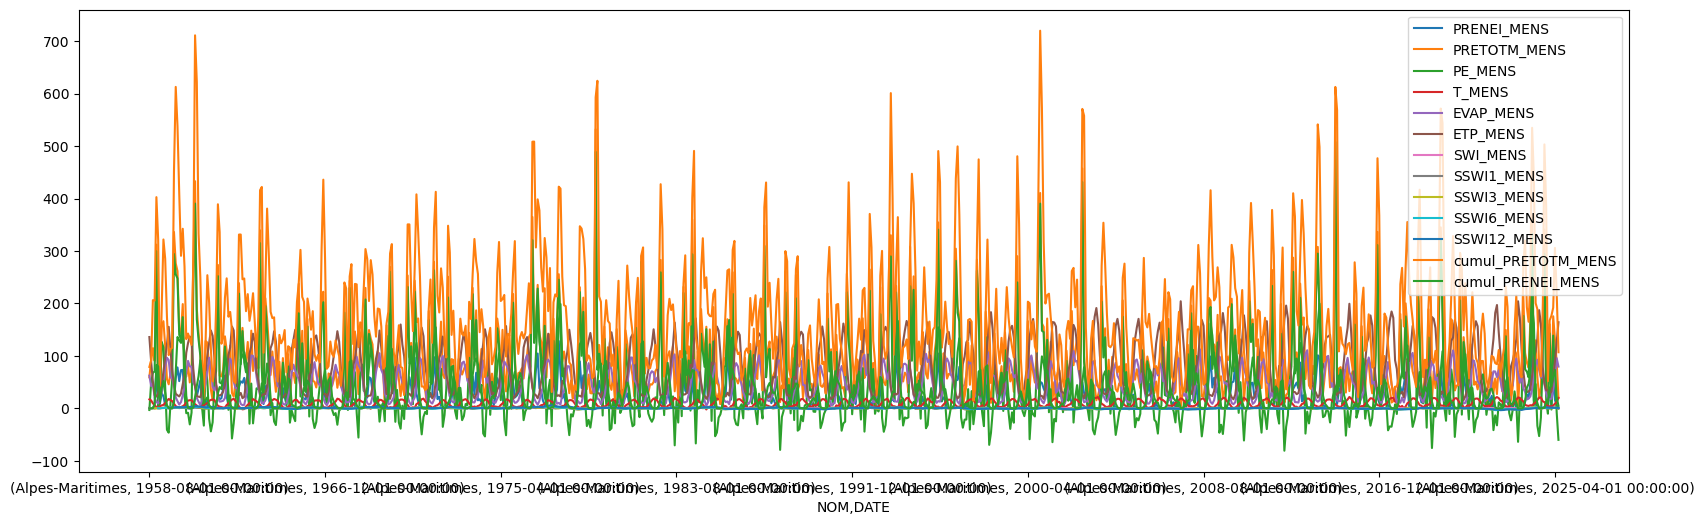

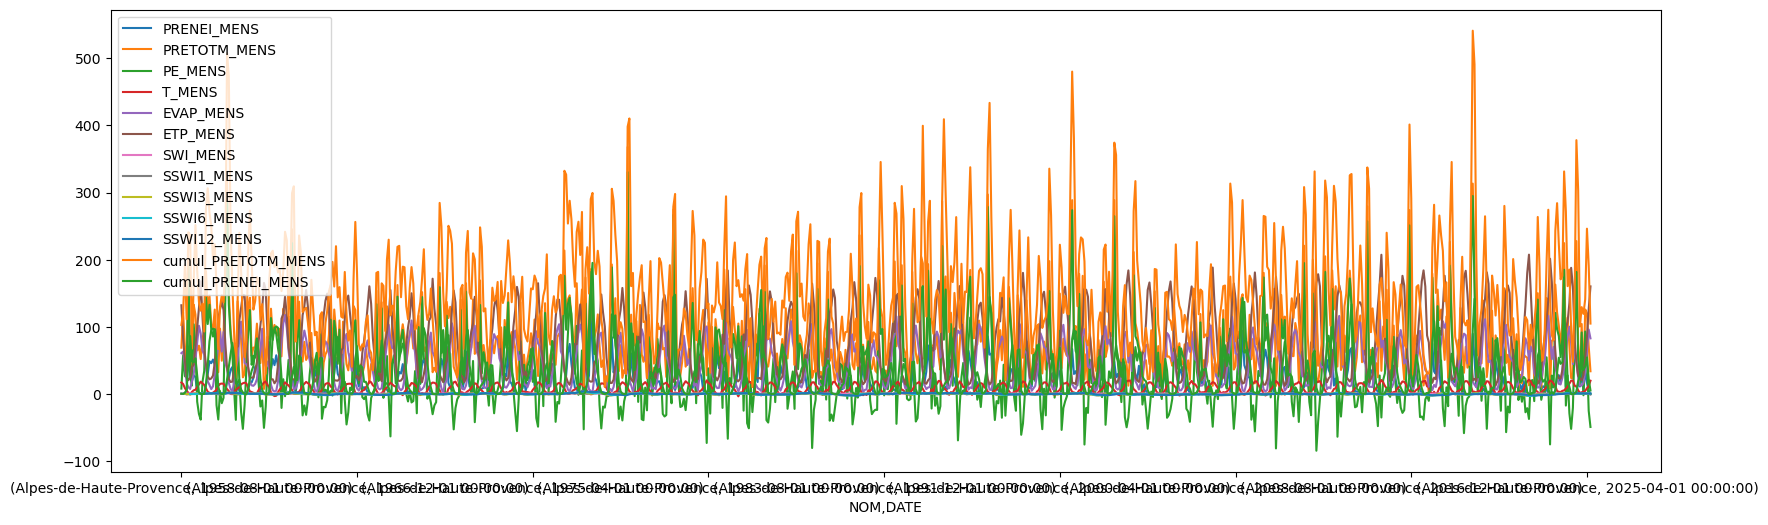

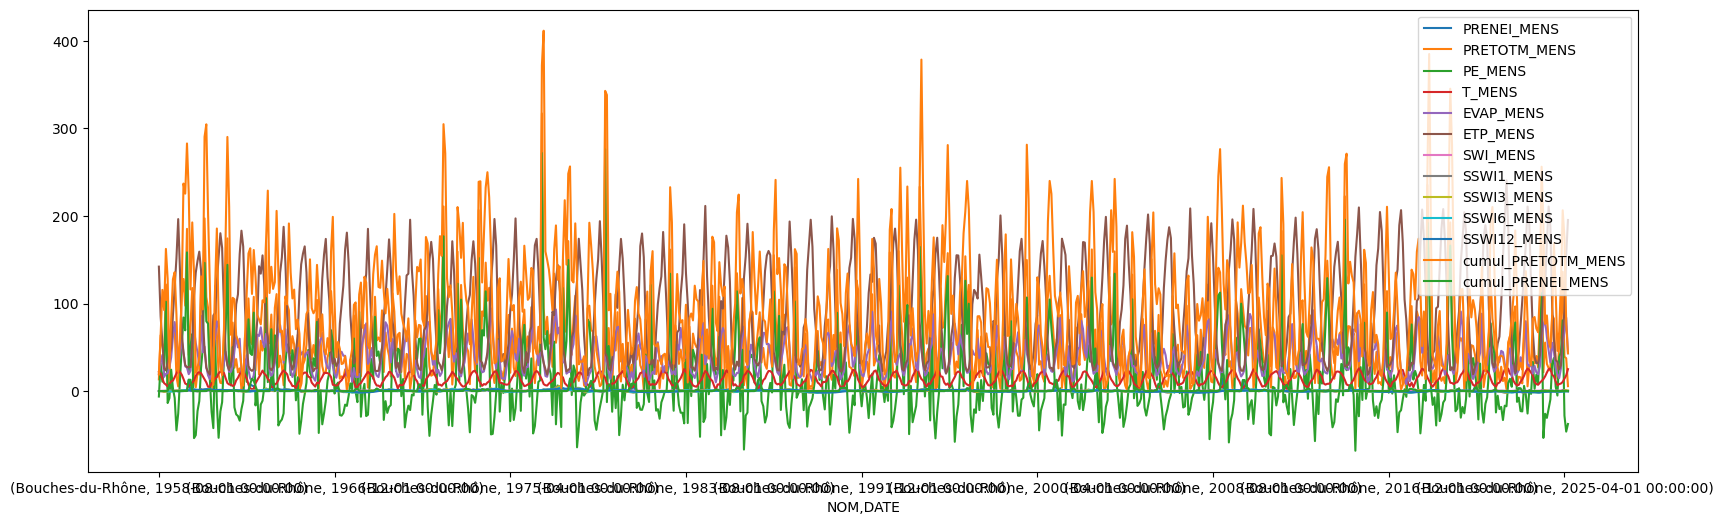

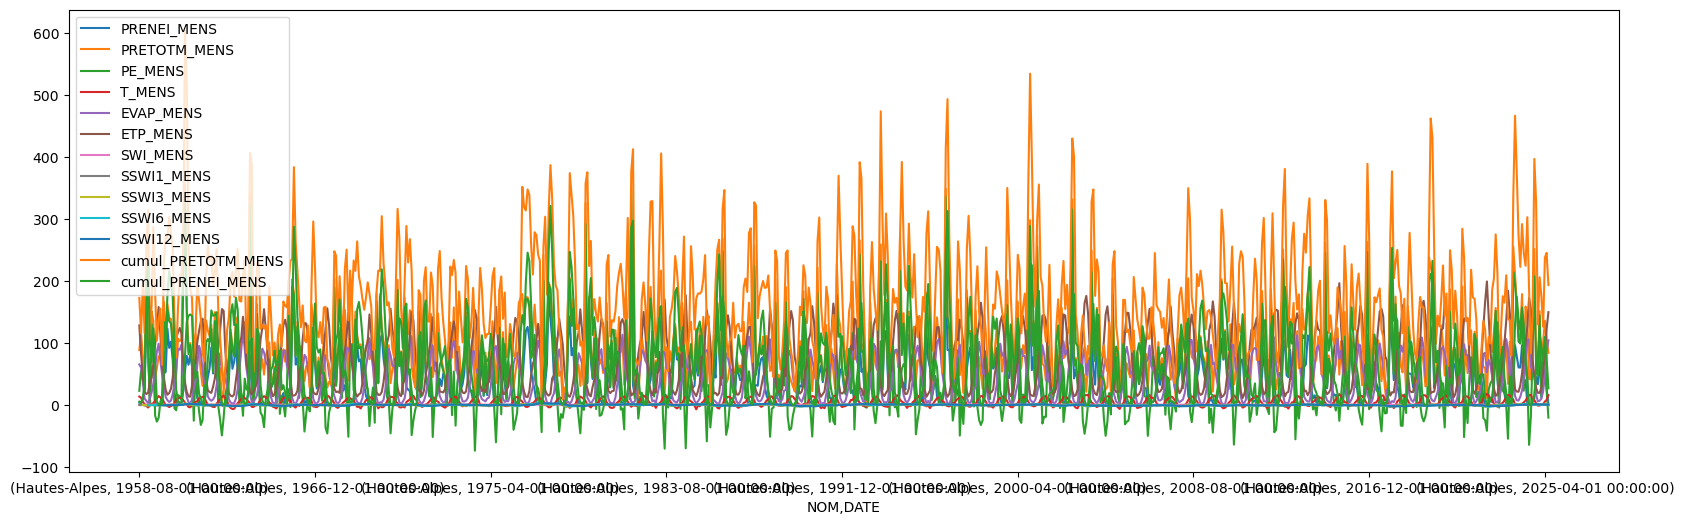

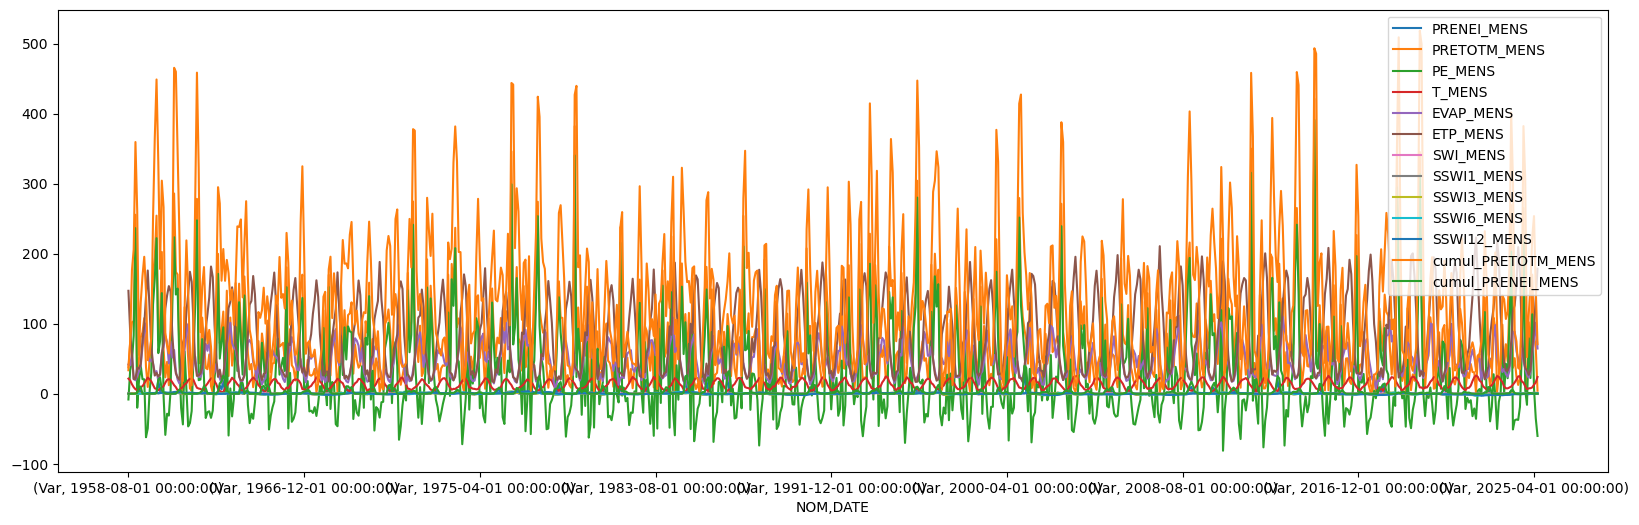

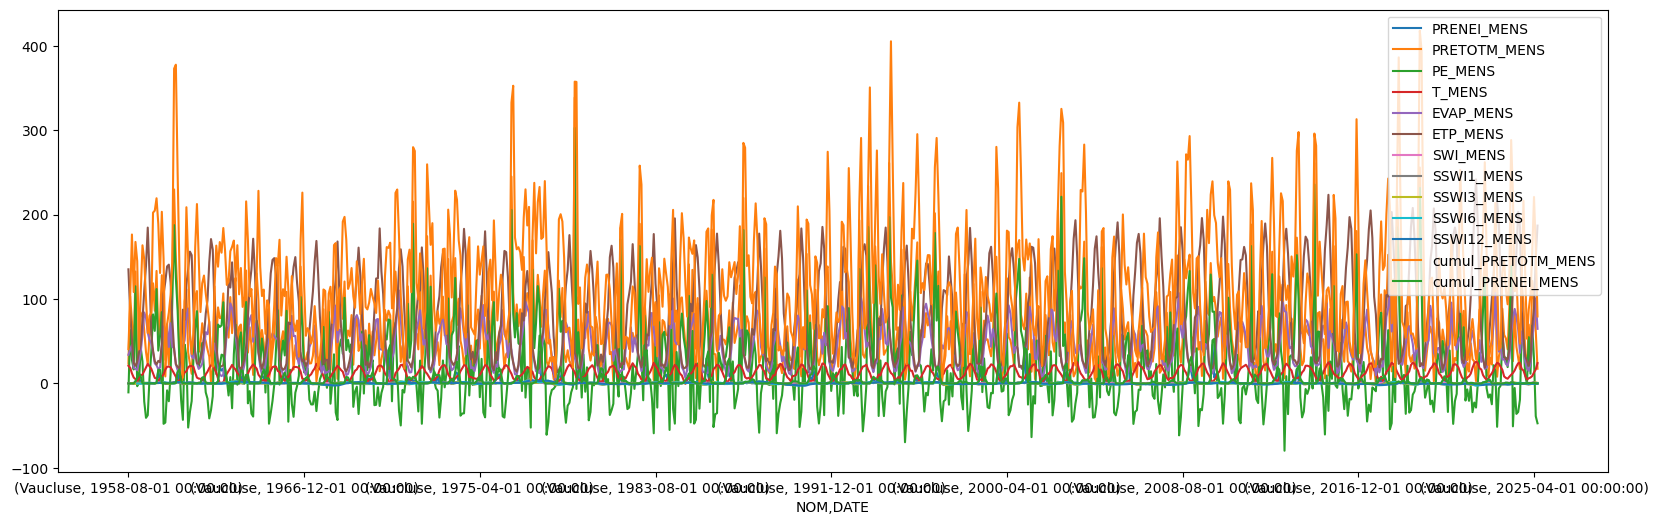

In [8]:
# change le backend pandas pour plotly
# pd.options.plotting.backend = "plotly"
# restaurer le backend par défaut
pd.options.plotting.backend = "matplotlib"

print(datetime.now().strftime('%d/%m/%y %H:%M'))
df.groupby(level=0).plot(figsize=(20, 6))
# définit la largeur et la hauteur du graphique pour chaque groupe
# df.groupby(level=0).plot(figsize=(12, 6))
# récère la figure courante
fig = plt.gcf()

plt.show()
# change backend plot pandas
# pd.options.plotting.backend = "plotly"


#### 9- SSWI - Graphique chronologique (il faut que les 4 indice standardisés SSWI soient sauvegardés dans le fichier Excel par le script "traitement par maille") - OPTIONNEL
SSWI calculé sur 1, 3, 6 et 12 mois : SSWI1_MENS, SSWI3_MENS, SSWI6_MENS, SSWI12_MENS

In [28]:
#================================
# Auteur: L. Duffar
# Juillet 2025
#================================
import plotly.graph_objects as go
import plotly.express as px
import plotly
# import seaborn as sns

############## Personalisation
list_param_comp= ['SSWI1_MENS', 'SSWI3_MENS', 'SSWI6_MENS', 'SSWI12_MENS'] # Paramètres SSWI pour les graphiques chronologiques

############## Initialisaiton
print(datetime.now().strftime('%d/%m/%y %H:%M'))
# période de retour et valeur de la loi normale centrée réduite
rec_dict= {'2 ans':0, '5 ans-sec': -0.841621, '10 ans-sec': -1.281551, '20 ans-sec': -1.644854, '50 ans-sec': -2.053749, '100 ans-sec': -3.090232}
palette = px.colors.qualitative.Safe  # https://matplotlib.org/stable/users/explain/colors/colormaps.html 
# palette = sns.color_palette().as_hex()

val_min= df[list_param_comp].min().min() # valeur minimale de tous les paramètres SSWI (chaque colonne/pararmètre puis min de toutes les colonnes)
val_max= df[list_param_comp].max().max() # valeur maximale de tous les paramètres SSWI

############# Plot
# définit un subplots contenant le même nombre de graphiques que de polygones
rows= len(df.index.get_level_values(nom_colonne_polygone).unique())
fig = plotly.subplots .make_subplots(rows= rows, cols= 1, subplot_titles= df.index.get_level_values(nom_colonne_polygone).unique().to_list(),
    shared_xaxes=True, vertical_spacing=0.03)

dates= df.index.get_level_values('DATE').unique() # liste des dates uniques dans l'index du dataframe
last_date= dates[-1].strftime('%Y-%m')

# taille de la figure et tire centré
fig.update_layout(height= 300 * rows, width= 1000, 
                  title_text= 'Indices mensuels de sécheresse SSWI sur 1, 3, 6 & 12 mois - ' + last_date, title_x= 0.5,
                  hovermode= "x unified", 
                  hoverlabel= dict(bgcolor= 'rgba(255,255,255,0.8)'))

# boucle sur les polygones
for i, polygone_name in enumerate(df.index.get_level_values(nom_colonne_polygone).unique().to_list()):
    # filtre le dataframe pour le polygone
    df_polygone = df.loc[polygone_name]
    if i==0:
        showlegend= True # affiche la légende pour le premier subplot
    else:
        showlegend= False # n'affiche pas la légende pour les autres subplots
    fig.add_trace(go.Scatter(x= dates, y= [0.]*len(dates), mode='lines', name='Médiane 1991-2020==0', line=dict(color='black', dash='solid'), showlegend=showlegend),
            row=i + 1, col=1) # Zéro)= médiane
    fig.add_trace(go.Scatter(x= dates, y= [rec_dict['5 ans-sec']]*len(dates), mode='lines', name='5 ans-sec=='+str(round(rec_dict['5 ans-sec'],2)), line=dict(color='gold', dash='dash'), showlegend=showlegend),
            row=i + 1, col=1) # Zéro)= 5 ans-sec
    fig.add_trace(go.Scatter(x= dates, y= [rec_dict['10 ans-sec']]*len(dates), mode='lines', name= '10 ans-sec=='+str(round(rec_dict['10 ans-sec'],2)), line=dict(color='darkorange', dash='dash'), showlegend=showlegend),
            row=i + 1, col=1) # 10 ans-sec
    fig.add_trace(go.Scatter(x= dates, y= [rec_dict['20 ans-sec']]*len(dates), mode='lines', name='20 ans-sec=='+str(round(rec_dict['20 ans-sec'],2)), line=dict(color='red', dash='dash'), showlegend=showlegend),
            row=i + 1, col=1) # 20 ans-sec
    fig.add_trace(go.Scatter(x= dates, y= [rec_dict['50 ans-sec']]*len(dates), mode='lines', name='50 ans-sec=='+str(round(rec_dict['50 ans-sec'],2)), line=dict(color='brown', dash='dash'), showlegend=showlegend),
            row=i + 1, col=1) # 50 ans-sec
    # fig.add_trace(go.Scatter(x= dates, y=[-2.326348]*len(dates), mode='lines', name='100 ans-sec', line=dict(color='saddlebrown', dash='dash'), showlegend=showlegend),
    #         row=i + 1, col=1) # 100 ans-sec

    # boucle sur les paramètres à tracer
    for j, param in enumerate(list_param_comp):
        width= 1 # épaisseur de la ligne par défaut
        if j== 2:
            width= 2 # épaisseur de la ligne pour le SSWI6
        color = palette[j % len(palette)]  # j = index de la catégorie/mois
        visible= 'legendonly'
        if j==0 or j==3:
            visible= True # affiche les paramètres SSWI1 et SSWI12
        # trace la série temporelle pour le paramètre et le polygone
        fig.add_trace(go.Scatter(x= dates, y= df_polygone[param], mode='lines', name= param[:10] + ' ' + polygone_name[:9], 
                                 line=dict(width= width, color=color), visible= visible),
                                 row=i + 1, col=1)
    # Définit le format d'affichage des nombres dans le hover (le nom de trace déjà défini ci-dessus sera automatiqument ajouté)
    fig.update_traces(hovertemplate= '%{y:0.3f}')
    # définit le lable de l'axe y pour chaque subplot
    fig.update_yaxes(title_text= 'Valeur loi normale centrée réduite', row=i + 1, col=1,
                    title_font=dict(size=12, color='black'),                     
                    #  range=[val_min, val_max],  # définit la même échelle pour tous les subplots
                        # tickvals= np.arange(val_min, val_max + 0.1, 0.2),  # graduations de l'axe y
                        # ticktext= [f"{x:.1f}" for x in np.arange(val_min, val_max + 0.1, 0.2)],  # étiquettes des graduations
                        # ticks='outside',  # graduations à l'extérieur de l'axe
                        # showticklabels=True,  # affiche les étiquettes des graduations
                        )

# Forcer la graduation de l'axe x pour chaque subplot, sinon l'argument hovermode= "x unified" conduit à graduer uniquement le dernier subplot
for i in range(1, rows + 1):
    fig.update_xaxes(showticklabels= True, row=i, col=1)
#     # graduation sans étiquette de l'axe x toute les années
#     fig.update_xaxes(tickvals= pd.date_range(start= '1958-01-01', end= fin_periode, freq='YE'), 
#                      ticklabelmode="period",
#                      row=i, col=1)

fig.update_yaxes(range=[val_min, val_max], matches='y')
fig.add_annotation(text= "https://github.com/loicduffar/meteo.data-Tools", xref= "paper", yref= "paper", x= 1., y= 0, xanchor= "left", yanchor= "auto",
            textangle= -90, showarrow= False, font= dict(size= 8, color= "black"))  
# sauvegarde de la figure dans un fichier HTML
file_out= os.path.join(folder_out, 'SSWI_MENS_1-12_' + last_date + '.html')
fig.write_html(file_out, include_plotlyjs='cdn') # sauvegarde de la figure dans un fichier HTML
print(f"Figure sauvegardée dans {file_out}")
fig.show()

02/08/25 21:26
Figure sauvegardée dans X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025\SSWI_MENS_1-12_2025-07.html


#### 10- Statistiques de dépassement d'une période de retour donnée EN CHANTIER

In [ ]:
display("df_periode[df_periode[param] < seuil]", df_periode[df_periode[param] < seuil])

display('ecart_mois', ecart_mois)
# display('ecart_mois remplace 1 par 0', ecart_mois.where(ecart_mois == 1, 0))#.cumsum()) 

# # df_periode
# display('ecart_mois remplace 0 par nan', ecart_mois.where(ecart_mois == 1, np.nan))
display("df_depassement['Durée']", df_depassement['Durée'])



'df_periode[df_periode[param] < seuil]'

,SSWI1_MENS,SSWI3_MENS,SSWI6_MENS,SSWI12_MENS
DATE,,,,
1978-11-01,-1.878525,-1.321475,-0.584754,0.452459
1978-12-01,-2.195574,-1.717049,-1.161967,-0.227705
1979-01-01,-1.419344,-2.039016,-1.362131,-0.458361
1981-02-01,-1.329508,-0.960656,-0.559180,0.240164
1985-11-01,-1.454262,-1.429016,-0.982787,-0.177869
1985-12-01,-1.492623,-1.554426,-1.315410,-0.673607
1986-12-01,-1.359508,-1.309180,-0.936230,-0.520820
1987-01-01,-1.583770,-1.455082,-1.212295,-0.583279


'ecart_mois'

0     NaN
1     1.0
2     1.0
3    25.0
4    57.0
5     1.0
6    12.0
7     1.0
Name: DATE, dtype: float64

KeyError: 'Durée'

In [ ]:
# Statistiques de dépassement d'une période de retour donnée

############## Personalisation
recurrence= '10 ans-sec' # période de retour à analyser

############## Initialisation
print(datetime.now().strftime('%d/%m/%y %H:%M'))
periode_list= ['1961-1990', '1991-2020', '2021-2030'] # périodes à analyser
rec_dict= {'2 ans':0, '5 ans-sec': -0.841621, '10 ans-sec': -1.281551, '20 ans-sec': -1.644854, '50 ans-sec': -2.053749, '100 ans-sec': -3.090232}

############## Traitement
df_stat_SSWI= pd.DataFrame(columns=[nom_colonne_polygone, 'SSWI', 'Période', 'nb_depassement', 'Durée'])
# Boucle sur les polygones
for i, polygone_name in enumerate(df.index.get_level_values(nom_colonne_polygone).unique().to_list()):
    # filtre le dataframe pour le polygone
    df_polygone = df.loc[polygone_name][list_param_comp]  # ne garde que les paramètres SSWI
    # Boucle sur les périodes
    for periode in periode_list:
        # filtre le dataframe pour la période
        df_periode = df_polygone.loc[(df_polygone.index.get_level_values('DATE') >= periode.split('-')[0]) & 
                                     (df_polygone.index.get_level_values('DATE') <= periode.split('-')[1])]
        # boucle sur les paramètres SSWI
        for param in list_param_comp:
            # filtre les données pour le paramètre et la période de retour
            # rec_dict = df_polygone[recurrence][param]
            # filtre les valeurs du paramètre qui dépassent la valeur de la période de retour
            seuil = rec_dict[recurrence]
            df_depassement = df_periode[df_periode[param] < seuil]
            nb_depassement = len(df_depassement)
            if nb_depassement > 0:
                # a partir de df_depassement.index.get_level_values('DATE') créer une série décalée de 1 ligne vers le bas pour calculer les jours consécutifs, avec np.nan en premier
                dates = pd.Series(df_depassement.index.get_level_values('DATE'))
                dates_shifted = dates.shift(1)
                # compter dans df_depassement le nombre de mois consécutifs pendant lesqules le dépassement dure 
                ecart_mois = (dates.dt.year - dates_shifted.dt.year) * 12 + (dates.dt.month - dates_shifted.dt.month)  # calcule la durée en mois
                # ecart_mois[0]= 1  # remplace le premier mois par 1 pour ne pas le compter comme nan
                # rempli df_depassement['Durée'] avec la somme des lignes consécutives de ecart_mois égale à 1
                # df_depassement['Durée'] = ecart_mois.where(ecart_mois == 1, np.nan)#.cumsum()  # cumule les mois consécutifs
                # boucle sur les ligne séparées par des nan
                for _, group in df_depassement.groupby((df_depassement['Durée'].isna()).cumsum()):
                    if group['Durée'].notna().any():
                        # calcule la durée en mois de chaque groupe consécutif
                        group_duration = group['Durée'].sum()
                        # ajoute la durée au DataFrame df_depassement
                        df_depassement.loc[group.index[0], 'Durée'] = group_duration

                        
                
                
                # df_depassement = df_depassement[df_depassement['Durée'] > 0]  # filtre les lignes où la durée est supérieure à 0
                # if df_depassement.empty:
                #     continue
                # calcule la durée moyenne des dépassements en mois
                # df_depassement['Durée'] = df_depassement['Durée'].mean()  # calcule la durée moyenne des dépassements en mois
                            
                duree_moyenne = df_depassement['Durée'].mean()  #   
                # créer une ligne dans le DataFrame df_stat_SSWI avec les statistiques de dépassement
                row = {
                    nom_colonne_polygone: polygone_name,
                    'SSWI': param,
                    'Période': periode,
                    # 'Récurrence': recurrence,
                    'nb_depassement': nb_depassement,
                    'Durée': duree_moyenne
                }
                df_stat_SSWI.loc[len(df_stat_SSWI)] = row
                    
# Réinitialiser l'index du DataFrame
df_stat_SSWI.reset_index(drop=True, inplace=True)
# Afficher les statistiques de dépassement
print(f"Statistiques de dépassement pour la période de retour {recurrence} :")
display(df_stat_SSWI)
# affiche dans l'explorateur avec panel
# import panel as pn
# pn.extension()  # prepare panel pour afficher df_stat_SSWI dans l'expl
# pn.serve(df_stat_SSWI.hvplot.table(width=1650, height=800))  # affiche df_stat_SSWI dans l'explorateur avec panel


02/07/25 22:10


KeyError: 'Durée'

In [ ]:
(dates.dt.year - dates_shifted.dt.year)


0    NaN
1    0.0
2    0.0
3    1.0
4    0.0
5    0.0
Name: DATE, dtype: float64